# 🎙️ Deepfake Voice Detection
### Pakistani Urdu-English Mixed Audio
---

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'librosa'], capture_output=True)
print("✅ librosa Installed!")

✅ librosa Installed!


## Step 1 — Import Libraries 

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

print('✅ Libraries are installed and imported successfully!')

✅ Libraries are installed and imported successfully!


## Step 2 — Set the Paths 

In [3]:
import os
import subprocess

# ── AUTO PATH DETECTION — works on ANY laptop, server, or cloud ──────────
BASE_DIR    = os.path.dirname(os.path.abspath('__file__'))
REAL_FOLDER = os.path.join(BASE_DIR, 'dataset', 'real')
FAKE_FOLDER = os.path.join(BASE_DIR, 'dataset', 'fake')
CSV_PATH    = os.path.join(BASE_DIR, 'metadata.csv')
# ─────────────────────────────────────────────────────────────────────────

# Verify folders exist
if not os.path.exists(REAL_FOLDER):
    print(f'❌ Real folder not found: {REAL_FOLDER}')
elif not os.path.exists(FAKE_FOLDER):
    print(f'❌ Fake folder not found: {FAKE_FOLDER}')
else:
    # ── Convert MP3 → WAV in fake folder ─────────────────────────────────
    mp3_files = [f for f in os.listdir(FAKE_FOLDER) if f.endswith('.mp3')]

    if mp3_files:
        print(f'🔄 Converting {len(mp3_files)} MP3 files to WAV...\n')
        success = 0
        failed  = 0

        for mp3_file in mp3_files:
            mp3_path = os.path.join(FAKE_FOLDER, mp3_file)
            wav_name = mp3_file.replace('.mp3', '.wav')
            wav_path = os.path.join(FAKE_FOLDER, wav_name)

            # Skip if WAV already exists — never overwrite
            if os.path.exists(wav_path):
                print(f'⚠️  Skipped (WAV exists): {wav_name}')
                continue

            result = subprocess.run([
                'ffmpeg',
                '-i',          mp3_path,
                '-ar',         '16000',  # 16kHz — matches real samples
                '-ac',         '1',      # mono
                '-sample_fmt', 's16',    # 16 bit high quality
                '-y',
                wav_path
            ], capture_output=True, text=True)

            if os.path.exists(wav_path):
                os.remove(mp3_path)      # delete MP3 after conversion
                print(f'✓ Converted : {mp3_file} → {wav_name}')
                success += 1
            else:
                print(f'✗ FAILED    : {mp3_file}')
                print(f'  Error     : {result.stderr[-150:]}')
                failed += 1

        print(f'\n✓ Converted : {success} files')
        print(f'✗ Failed    : {failed} files\n')
    else:
        print('✅ No MP3 files found — all fake files already WAV!\n')

    # ── Final count ───────────────────────────────────────────────────────
    real_files = [f for f in os.listdir(REAL_FOLDER) if f.endswith('.wav')]
    fake_files = [f for f in os.listdir(FAKE_FOLDER) if f.endswith('.wav')]

    print(f'🟢 Real files : {len(real_files)}')
    print(f'🔴 Fake files : {len(fake_files)}')
    print(f'📊 Total      : {len(real_files) + len(fake_files)}')

    if len(real_files) == len(fake_files):
        print(f'\n✅ Dataset balanced! Ready for training.')
    else:
        print(f'\n⚠️  Dataset unbalanced — {abs(len(real_files) - len(fake_files))} files difference.')

✅ No MP3 files found — all fake files already WAV!

🟢 Real files : 151
🔴 Fake files : 151
📊 Total      : 302

✅ Dataset balanced! Ready for training.


## Step 3 — Update Dataset CSV
Save all file records into metadata.csv with their labels (real/fake).

In [4]:
import os
import csv
from datetime import datetime

# ── Create/Update metadata.csv ────────────────────────────────────────────
rows = []

# Add real files
for fname in sorted(real_files):
    rows.append({
        'filename'     : fname,
        'label'        : 'real',
        'source'       : 'youtube',
        'language_mix' : 'urdu+english',
        'date_added'   : datetime.today().strftime('%Y-%m-%d')
    })

# Add fake files
for fname in sorted(fake_files):
    rows.append({
        'filename'     : fname,
        'label'        : 'fake',
        'source'       : 'elevenlabs',
        'language_mix' : 'urdu+english',
        'date_added'   : datetime.today().strftime('%Y-%m-%d')
    })

# Write to CSV
with open(CSV_PATH, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

# Verify
df = pd.read_csv(CSV_PATH)
print(f'✅ metadata.csv updated successfully!')
print(f'📊 Total records : {len(df)}')
print(f'🟢 Real records  : {len(df[df["label"] == "real"])}')
print(f'🔴 Fake records  : {len(df[df["label"] == "fake"])}')
print(f'\nFirst 3 rows:')
print(df.head(3).to_string(index=False))
print(f'\nLast 3 rows:')
print(df.tail(3).to_string(index=False))

✅ metadata.csv updated successfully!
📊 Total records : 302
🟢 Real records  : 151
🔴 Fake records  : 151

First 3 rows:
    filename label  source language_mix date_added
real_001.wav  real youtube urdu+english 2026-05-24
real_002.wav  real youtube urdu+english 2026-05-24
real_003.wav  real youtube urdu+english 2026-05-24

Last 3 rows:
                                                                               filename label     source language_mix date_added
शांत-अनुभवी-पुरुष-2026-05-07-06-41-Aaj-kal-bachon-ke-liye-healthy-eating-habits-dev.wav  fake elevenlabs urdu+english 2026-05-24
शांत-अनुभवी-पुरुष-2026-05-07-06-41-Yeh-traffic-problem-seriously-address-karni-chah.wav  fake elevenlabs urdu+english 2026-05-24
शांत-अनुभवी-पुरुष-2026-05-07-06-43-Yeh-tailoring-shop-ka-kaam-bohot-neat-hai,-stitc.wav  fake elevenlabs urdu+english 2026-05-24


## Step 4 — Split All Audio Clips into 3 Second Chunks
Instead of trimming, we split each clip into multiple 3 second chunks.
This preserves all audio data and increases dataset size significantly.
- Each chunk is exactly 3 seconds (48000 samples at 16kHz)
- Chunks shorter than 3 seconds are discarded
- Original files are kept safe — chunks saved to new folders

In [5]:
import librosa
import soundfile as sf
import numpy as np
import os
import csv
from datetime import datetime

TARGET_DURATION = 3
TARGET_SR       = 16000
TARGET_LENGTH   = TARGET_DURATION * TARGET_SR  # 48000 samples

# ── Output folders for chunks ─────────────────────────────────────────────
REAL_CHUNKS_FOLDER = os.path.join(BASE_DIR, 'dataset', 'real_chunks')
FAKE_CHUNKS_FOLDER = os.path.join(BASE_DIR, 'dataset', 'fake_chunks')

os.makedirs(REAL_CHUNKS_FOLDER, exist_ok=True)
os.makedirs(FAKE_CHUNKS_FOLDER, exist_ok=True)

def split_into_chunks(file_path, output_folder, label, base_name):
    """
    Split one audio file into multiple 3 second chunks.
    Returns number of chunks created.
    """
    try:
        audio, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
        total_chunks = len(audio) // TARGET_LENGTH
        chunks_saved = 0

        for i in range(total_chunks):
            start  = i * TARGET_LENGTH
            end    = start + TARGET_LENGTH
            chunk  = audio[start:end]

            # Save chunk
            chunk_name = f'{base_name}_chunk{i+1:02d}.wav'
            chunk_path = os.path.join(output_folder, chunk_name)
            sf.write(chunk_path, chunk, TARGET_SR)
            chunks_saved += 1

        return chunks_saved

    except Exception as e:
        print(f'❌ Error: {file_path} → {e}')
        return 0

# ── Process real files ────────────────────────────────────────────────────
print('Splitting real files into 3 second chunks...\n')
real_total_chunks = 0

for fname in sorted(real_files):
    input_path = os.path.join(REAL_FOLDER, fname)
    base_name  = os.path.splitext(fname)[0]
    chunks     = split_into_chunks(input_path, REAL_CHUNKS_FOLDER, 'real', base_name)
    real_total_chunks += chunks

print(f'✅ Real chunks created : {real_total_chunks}')

# ── Process fake files ────────────────────────────────────────────────────
print('\nSplitting fake files into 3 second chunks...\n')
fake_total_chunks = 0

for fname in sorted(fake_files):
    input_path = os.path.join(FAKE_FOLDER, fname)
    base_name  = os.path.splitext(fname)[0]
    chunks     = split_into_chunks(input_path, FAKE_CHUNKS_FOLDER, 'fake', base_name)
    fake_total_chunks += chunks

print(f'✅ Fake chunks created : {fake_total_chunks}')

# ── Update variables for next steps ──────────────────────────────────────
real_chunk_files = sorted([f for f in os.listdir(REAL_CHUNKS_FOLDER) if f.endswith('.wav')])
fake_chunk_files = sorted([f for f in os.listdir(FAKE_CHUNKS_FOLDER) if f.endswith('.wav')])

# ── Summary ───────────────────────────────────────────────────────────────
print(f'\n{"="*50}')
print(f'Original real files  : {len(real_files)}')
print(f'Original fake files  : {len(fake_files)}')
print(f'{"="*50}')
print(f'Real chunks created  : {len(real_chunk_files)}')
print(f'Fake chunks created  : {len(fake_chunk_files)}')
print(f'Total chunks         : {len(real_chunk_files) + len(fake_chunk_files)}')
print(f'{"="*50}')
print(f'\n✅ Original files safe in dataset/real/ and dataset/fake/')
print(f'✅ Chunks saved in dataset/real_chunks/ and dataset/fake_chunks/')
print(f'✅ Ready for MFCC feature extraction!')

Splitting real files into 3 second chunks...

✅ Real chunks created : 536

Splitting fake files into 3 second chunks...

✅ Fake chunks created : 327

Original real files  : 151
Original fake files  : 151
Real chunks created  : 536
Fake chunks created  : 327
Total chunks         : 863

✅ Original files safe in dataset/real/ and dataset/fake/
✅ Chunks saved in dataset/real_chunks/ and dataset/fake_chunks/
✅ Ready for MFCC feature extraction!


## Step 5 — Extract MFCC Features from Chunks
Convert all audio chunks into numbers (features) that the model can understand.
- MFCC = Mel Frequency Cepstral Coefficients
- Each 3 second chunk → 40 numbers describing its voice pattern
- Real and fake voices have different MFCC patterns
- This is what the model actually trains on

In [6]:
import numpy as np
import librosa
import os

def extract_mfcc(file_path, n_mfcc=40):
    """
    Extract 40 MFCC features from a 3 second audio chunk.
    Input  : audio file path
    Output : 40 numbers describing the voice pattern
    """
    try:
        audio, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
        mfcc      = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc, axis=1)  # average across time → 40 numbers
    except Exception as e:
        print(f'❌ Error: {file_path} → {e}')
        return None

# ── Extract features from all chunks ─────────────────────────────────────
X = []   # features
y = []   # labels (0=real, 1=fake)

# Real chunks
print('Extracting features from real chunks...')
real_errors = 0
for fname in sorted(real_chunk_files):
    fpath    = os.path.join(REAL_CHUNKS_FOLDER, fname)
    features = extract_mfcc(fpath)
    if features is not None:
        X.append(features)
        y.append(0)   # 0 = real
    else:
        real_errors += 1

print(f'✅ Real features extracted : {len([i for i in y if i == 0])}')
print(f'❌ Real errors            : {real_errors}')

# Fake chunks
print('\nExtracting features from fake chunks...')
fake_errors = 0
for fname in sorted(fake_chunk_files):
    fpath    = os.path.join(FAKE_CHUNKS_FOLDER, fname)
    features = extract_mfcc(fpath)
    if features is not None:
        X.append(features)
        y.append(1)   # 1 = fake
    else:
        fake_errors += 1

print(f'✅ Fake features extracted : {len([i for i in y if i == 1])}')
print(f'❌ Fake errors            : {fake_errors}')

# ── Convert to numpy arrays ───────────────────────────────────────────────
X = np.array(X)
y = np.array(y)

print(f'\n{"="*45}')
print(f'Feature matrix shape : {X.shape}')
print(f'  → {X.shape[0]} total samples')
print(f'  → {X.shape[1]} features per sample')
print(f'Real samples         : {np.sum(y == 0)}')
print(f'Fake samples         : {np.sum(y == 1)}')
print(f'{"="*45}')
print(f'✅ Feature extraction complete! Ready for training.')

Extracting features from real chunks...
✅ Real features extracted : 536
❌ Real errors            : 0

Extracting features from fake chunks...
✅ Fake features extracted : 327
❌ Fake errors            : 0

Feature matrix shape : (863, 40)
  → 863 total samples
  → 40 features per sample
Real samples         : 536
Fake samples         : 327
✅ Feature extraction complete! Ready for training.


## Step 6 — Train/Test Split and Normalize
Split dataset into 80% training and 20% testing.
Normalize features so all values are on the same scale.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Train/Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,         # 20% for testing
    random_state = 42,          # reproducible results
    stratify     = y            # keep real/fake ratio same in both sets
)

# ── Normalize features ────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn scale from training data
X_test  = scaler.transform(X_test)        # apply same scale to test data

# ── Summary ───────────────────────────────────────────────────────────────
print(f'{"="*45}')
print(f'Total samples    : {len(X)}')
print(f'Training samples : {len(X_train)} (80%)')
print(f'Testing samples  : {len(X_test)}  (20%)')
print(f'{"="*45}')
print(f'Training — Real  : {sum(y_train == 0)}')
print(f'Training — Fake  : {sum(y_train == 1)}')
print(f'Testing  — Real  : {sum(y_test == 0)}')
print(f'Testing  — Fake  : {sum(y_test == 1)}')
print(f'{"="*45}')
print(f'✅ Split complete! Ready for model training.')

Total samples    : 863
Training samples : 690 (80%)
Testing samples  : 173  (20%)
Training — Real  : 429
Training — Fake  : 261
Testing  — Real  : 107
Testing  — Fake  : 66
✅ Split complete! Ready for model training.


## Step 7 — Train the Model
Train a Random Forest classifier on the extracted MFCC features.
- 100 decision trees working together
- class_weight='balanced' handles the imbalance between real and fake chunks
- Each tree votes — majority wins the final prediction

In [9]:
from sklearn.ensemble import RandomForestClassifier
import time

# ── Train Random Forest Model ─────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators = 100,          # 100 decision trees
    random_state = 42,           # reproducible results
    class_weight = 'balanced',   # handles real/fake imbalance
    n_jobs       = -1            # use all CPU cores — faster training
)

print('Training started...')
start_time = time.time()

model.fit(X_train, y_train)

end_time     = time.time()
training_sec = round(end_time - start_time, 2)

print(f'✅ Training complete!')
print(f'⏱️  Time taken : {training_sec} seconds')
print(f'🌲 Trees built : {model.n_estimators}')
print(f'📊 Features    : {model.n_features_in_}')

Training started...
✅ Training complete!
⏱️  Time taken : 0.22 seconds
🌲 Trees built : 100
📊 Features    : 40


## Step 8 — Evaluate the Model
Test the trained model on unseen data and measure its performance.
- Precision : out of all predicted fake, how many were actually fake
- Recall    : out of all actual fake, how many did we correctly detect
- F1 Score  : balance between precision and recall
- Accuracy  : overall correct predictions percentage

           MODEL EVALUATION RESULTS
              precision    recall  f1-score   support

        Real       0.95      0.97      0.96       107
        Fake       0.95      0.92      0.94        66

    accuracy                           0.95       173
   macro avg       0.95      0.95      0.95       173
weighted avg       0.95      0.95      0.95       173



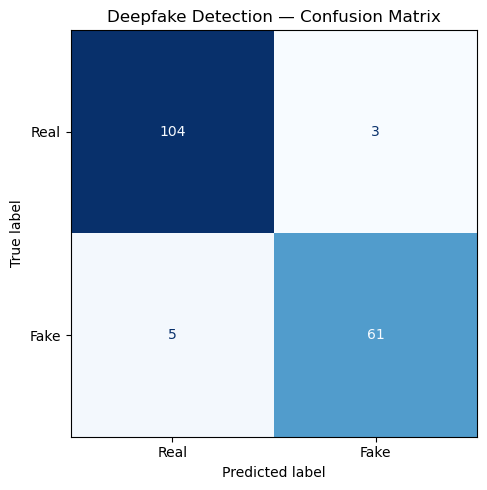

Total test samples   : 173
Correct predictions  : 165
Wrong predictions    : 8
Overall accuracy     : 95.4%
Real voices correct  : 104 / 107
Fake voices correct  : 61 / 66
🌟 Excellent! Model is performing very well.


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ── Predictions ───────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

# ── Classification Report ─────────────────────────────────────────────────
print('=' * 50)
print('           MODEL EVALUATION RESULTS')
print('=' * 50)
print(classification_report(
    y_test, y_pred,
    target_names = ['Real', 'Fake']
))

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Real', 'Fake']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Deepfake Detection — Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Simple Summary ────────────────────────────────────────────────────────
total        = len(y_test)
correct      = sum(y_pred == y_test)
wrong        = total - correct
accuracy     = correct / total * 100

real_correct = sum((y_pred == 0) & (y_test == 0))
fake_correct = sum((y_pred == 1) & (y_test == 1))

print('=' * 50)
print(f'Total test samples   : {total}')
print(f'Correct predictions  : {correct}')
print(f'Wrong predictions    : {wrong}')
print(f'Overall accuracy     : {accuracy:.1f}%')
print('=' * 50)
print(f'Real voices correct  : {real_correct} / {sum(y_test == 0)}')
print(f'Fake voices correct  : {fake_correct} / {sum(y_test == 1)}')
print('=' * 50)

if accuracy >= 90:
    print('🌟 Excellent! Model is performing very well.')
elif accuracy >= 80:
    print('✅ Good! Model is performing well.')
elif accuracy >= 70:
    print('⚠️  Acceptable. Model needs some improvement.')
else:
    print('❌ Model needs significant improvement.')

## Step 9 — Save the Trained Model
Save the trained model and scaler to disk so we don't need to retrain every time.
- model.pkl  : the trained Random Forest classifier
- scaler.pkl : the normalization scaler fitted on training data
- Both must be saved together — scaler is needed for predictions

In [11]:
import pickle
import os

# ── Save model and scaler ─────────────────────────────────────────────────
MODEL_PATH  = os.path.join(BASE_DIR, 'model.pkl')
SCALER_PATH = os.path.join(BASE_DIR, 'scaler.pkl')

# Save model
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)

# Save scaler
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

# Verify both files saved correctly
model_size  = os.path.getsize(MODEL_PATH)  / 1024
scaler_size = os.path.getsize(SCALER_PATH) / 1024

print(f'✅ Model saved!')
print(f'   Path : {MODEL_PATH}')
print(f'   Size : {model_size:.1f} KB')
print(f'')
print(f'✅ Scaler saved!')
print(f'   Path : {SCALER_PATH}')
print(f'   Size : {scaler_size:.1f} KB')
print(f'')
print(f'To load later use:')
print(f'   model  = pickle.load(open("model.pkl",  "rb"))')
print(f'   scaler = pickle.load(open("scaler.pkl", "rb"))')

✅ Model saved!
   Path : d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\model.pkl
   Size : 882.3 KB

✅ Scaler saved!
   Path : d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\scaler.pkl
   Size : 1.4 KB

To load later use:
   model  = pickle.load(open("model.pkl",  "rb"))
   scaler = pickle.load(open("scaler.pkl", "rb"))


## Step 10 — Test on a New Audio File
Give any audio file to the model and it will predict:
- Whether it is REAL or FAKE
- Confidence percentage
- Result for each 3 second chunk

In [23]:
import librosa
import numpy as np
import pickle
import os

def predict_audio(file_path):
    """
    Give any audio file — model will predict Real or Fake.
    Audio is split into 3 second chunks and each chunk is analyzed.
    Final result is based on majority vote of all chunks.
    """
    print(f'{"="*50}')
    print(f'Analyzing : {os.path.basename(file_path)}')
    print(f'{"="*50}')

    # Load audio
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
    except Exception as e:
        print(f'❌ Could not load file: {e}')
        return

    # Split into 3 second chunks
    chunk_size   = 3 * 16000   # 48000 samples
    total_chunks = len(audio) // chunk_size

    if total_chunks == 0:
        # Audio shorter than 3 seconds — pad and predict as single chunk
        padding      = chunk_size - len(audio)
        audio        = np.pad(audio, (0, padding), mode='constant')
        total_chunks = 1

    print(f'Duration     : {len(audio)/16000:.1f} seconds')
    print(f'Total chunks : {total_chunks} x 3 seconds')
    print(f'{"="*50}')

    chunk_results = []

    for i in range(total_chunks):
        start = i * chunk_size
        end   = start + chunk_size
        chunk = audio[start:end]

        # Extract MFCC features
        mfcc     = librosa.feature.mfcc(y=chunk, sr=16000, n_mfcc=40)
        features = np.mean(mfcc, axis=1).reshape(1, -1)

        # Normalize
        features_scaled = scaler.transform(features)

        # Predict
        prediction = model.predict(features_scaled)[0]
        confidence = model.predict_proba(features_scaled)[0]
        conf_pct   = confidence[prediction] * 100
        label      = 'FAKE' if prediction == 1 else 'REAL'

        chunk_results.append({
            'chunk'      : i + 1,
            'start'      : i * 3,
            'end'        : (i + 1) * 3,
            'label'      : label,
            'confidence' : conf_pct
        })

        print(f'Chunk {i+1} [{i*3}s — {(i+1)*3}s] : {label} ({conf_pct:.1f}%)')

    # Final verdict — majority vote
    fake_chunks = sum(1 for r in chunk_results if r['label'] == 'FAKE')
    real_chunks = sum(1 for r in chunk_results if r['label'] == 'REAL')
    avg_conf    = sum(r['confidence'] for r in chunk_results) / len(chunk_results)

    final = 'FAKE' if fake_chunks > real_chunks else 'REAL'

    print(f'{"="*50}')
    print(f'Real chunks      : {real_chunks}')
    print(f'Fake chunks      : {fake_chunks}')
    print(f'Average confidence : {avg_conf:.1f}%')
    print(f'{"="*50}')

    if final == 'FAKE':
        print(f'FINAL RESULT : FAKE (AI Generated Voice)')
    else:
        print(f'FINAL RESULT : REAL (Human Voice)')

    print(f'{"="*50}')

    return chunk_results, final, avg_conf

# ── Test on a sample file ─────────────────────────────────────────────────
# Change this path to any wav file you want to test
TEST_FILE = os.path.join(BASE_DIR, 'dataset', 'fake', 'fake_002.wav')

results, final, avg_conf = predict_audio(TEST_FILE)

Analyzing : fake_002.wav
Duration     : 7.9 seconds
Total chunks : 2 x 3 seconds
Chunk 1 [0s — 3s] : FAKE (86.0%)
Chunk 2 [3s — 6s] : FAKE (93.0%)
Real chunks      : 0
Fake chunks      : 2
Average confidence : 89.5%
FINAL RESULT : FAKE (AI Generated Voice)


## Step 11 — Generate PDF Report
Generates a professional PDF report with:
- Clear verdict card at the top
- Plain English explanations for every section
- Visual timeline with colored blocks
- Feature analysis with human readable names
- Normal range check with Within/Outside range labels
- Suspicion bar in chunk table
- Smart title that changes based on Real or Fake result

In [24]:
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import librosa
import os
from datetime import datetime
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 Image, Table, TableStyle, HRFlowable)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.platypus import KeepTogether

# ── Output folders ────────────────────────────────────────────────────────
REPORTS_FOLDER = os.path.join(BASE_DIR, 'audio_reports')
CHARTS_PATH    = os.path.join(BASE_DIR, 'audio_reports', 'charts')
os.makedirs(REPORTS_FOLDER, exist_ok=True)
os.makedirs(CHARTS_PATH,    exist_ok=True)

# Unique report name
audio_name  = os.path.splitext(os.path.basename(TEST_FILE))[0]
timestamp   = datetime.now().strftime('%Y%m%d_%H%M%S')
REPORT_PATH = os.path.join(REPORTS_FOLDER, f'{audio_name}_{timestamp}.pdf')

print(f'Report will be saved to:')
print(f'{REPORT_PATH}\n')

# ── Human readable MFCC names ─────────────────────────────────────────────
MFCC_NAMES = {
    'MFCC_1'  : 'Overall Energy Level',
    'MFCC_2'  : 'Spectral Shape (Brightness)',
    'MFCC_3'  : 'Voice Texture Coarseness',
    'MFCC_4'  : 'Vocal Tract Resonance',
    'MFCC_5'  : 'Nasal Resonance Pattern',
    'MFCC_6'  : 'Mid Frequency Tone',
    'MFCC_7'  : 'Articulation Clarity',
    'MFCC_8'  : 'Pitch Variation Pattern',
    'MFCC_9'  : 'Voice Smoothness',
    'MFCC_10' : 'Spectral Fine Structure',
    'MFCC_11' : 'High Frequency Detail',
    'MFCC_12' : 'Breathiness Level',
    'MFCC_13' : 'Consonant Sharpness',
    'MFCC_14' : 'Vowel Quality',
    'MFCC_15' : 'Rhythm Pattern',
    'MFCC_16' : 'Stress Pattern',
    'MFCC_17' : 'Speaking Rate Variation',
    'MFCC_18' : 'Voice Onset Pattern',
    'MFCC_19' : 'Intonation Contour',
    'MFCC_20' : 'Micro Pitch Fluctuation',
    'MFCC_21' : 'Spectral Tilt',
    'MFCC_22' : 'Formant Transition Speed',
    'MFCC_23' : 'Voice Naturalness',
    'MFCC_24' : 'Glottal Pulse Pattern',
    'MFCC_25' : 'Subglottal Resonance',
    'MFCC_26' : 'Palatal Resonance',
    'MFCC_27' : 'Velar Resonance',
    'MFCC_28' : 'Labial Sound Pattern',
    'MFCC_29' : 'Dental Sound Texture',
    'MFCC_30' : 'Fricative Pattern',
    'MFCC_31' : 'Plosive Burst Pattern',
    'MFCC_32' : 'Nasal Murmur Detail',
    'MFCC_33' : 'Liquid Sound Texture',
    'MFCC_34' : 'Glide Transition Pattern',
    'MFCC_35' : 'Voice Tremor Detail',
    'MFCC_36' : 'Micro Rhythm Pattern',
    'MFCC_37' : 'Spectral Envelope Shape',
    'MFCC_38' : 'Harmonic Structure',
    'MFCC_39' : 'Noise Floor Pattern',
    'MFCC_40' : 'Ultra Fine Voice Texture',
}

# ── Colors ────────────────────────────────────────────────────────────────
FAKE_RED    = '#E24B4A'
FAKE_LIGHT  = '#FCEBEB'
REAL_GREEN  = '#639922'
REAL_LIGHT  = '#EAF3DE'
NORMAL_BLUE = '#85B7EB'
GRAY        = '#888780'
DARK_GRAY   = '#444441'

# ── Chart 1 — Timeline ────────────────────────────────────────────────────
def generate_timeline_chart(results, filename):
    fig, ax = plt.subplots(figsize=(10, 2.5))
    fig.patch.set_facecolor('white')

    for r in results:
        color     = FAKE_RED   if r['label'] == 'FAKE' else REAL_GREEN
        edgecolor = '#A32D2D'  if r['label'] == 'FAKE' else '#27500A'
        ax.barh(
            y=0, width=3, left=r['start'],
            color=color, alpha=0.85, height=0.6,
            edgecolor=edgecolor, linewidth=1.5
        )
        ax.text(
            r['start'] + 1.5, 0.18,
            r['label'],
            ha='center', va='center',
            fontsize=10, color='white', fontweight='bold'
        )
        ax.text(
            r['start'] + 1.5, -0.15,
            f"{r['confidence']:.0f}% confident",
            ha='center', va='center',
            fontsize=9, color='white'
        )

    # Time labels below
    total_duration = results[-1]['end']
    for r in results:
        ax.text(
            r['start'], -0.42,
            f"{r['start']}s",
            ha='center', fontsize=9,
            color=DARK_GRAY
        )
    ax.text(
        total_duration, -0.42,
        f"{total_duration}s",
        ha='center', fontsize=9,
        color=DARK_GRAY
    )

    fake_patch = mpatches.Patch(color=FAKE_RED,   label='FAKE — AI Generated')
    real_patch = mpatches.Patch(color=REAL_GREEN, label='REAL — Human Voice')
    ax.legend(
        handles=[fake_patch, real_patch],
        loc='upper right', fontsize=9,
        framealpha=0.9
    )

    ax.set_xlim(-0.2, total_duration + 0.2)
    ax.set_ylim(-0.55, 0.55)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_title(
        'Each block = 3 seconds of audio. Color shows the verdict for that segment.',
        fontsize=9, color=GRAY, pad=8
    )

    plt.tight_layout()
    chart_path = os.path.join(CHARTS_PATH, f'{filename}_{timestamp}_timeline.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.close()
    return chart_path

# ── Chart 2 — SHAP + Range side by side ──────────────────────────────────
def generate_analysis_chart(chunk_results, filename, final):

    explainer = shap.TreeExplainer(model)

    # Pick most suspicious chunk
    fake_chunks = [r for r in chunk_results if r['label'] == 'FAKE']
    target      = fake_chunks[0] if fake_chunks else chunk_results[0]

    audio, sr = librosa.load(TEST_FILE, sr=16000, mono=True)
    start     = target['start'] * 16000
    end       = start + (3 * 16000)
    chunk     = audio[start:end]

    mfcc            = librosa.feature.mfcc(y=chunk, sr=16000, n_mfcc=40)
    features        = np.mean(mfcc, axis=1).reshape(1, -1)
    features_scaled = scaler.transform(features)

    shap_values = explainer.shap_values(features_scaled)

    if isinstance(shap_values, list):
        vals = np.array(shap_values[1][0]).flatten()
    elif hasattr(shap_values, 'values'):
        vals = np.array(shap_values.values).flatten()
        if len(vals) > 40:
            vals = vals[:40]
    else:
        vals = np.array(shap_values).flatten()
        if len(vals) > 40:
            vals = vals[:40]
    vals = vals[:40]

    feature_names = [f'MFCC_{i+1}' for i in range(40)]
    abs_vals      = np.abs(vals)
    indices       = np.argsort(abs_vals)[-12:]
    indices       = [int(i) for i in indices]
    top_vals      = [vals[i] for i in indices]
    top_keys      = [feature_names[i] for i in indices]
    top_names     = [f"{MFCC_NAMES.get(k, k)}\n({k})" for k in top_keys]
    bar_colors    = [FAKE_RED if v > 0 else REAL_GREEN for v in top_vals]

    # Real ranges from training
    real_idx      = [i for i, l in enumerate(y_train) if l == 0]
    real_feats    = X_train[real_idx]
    real_means    = np.mean(real_feats, axis=0)
    real_stds     = np.std(real_feats,  axis=0)

    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_facecolor('white')
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.45)

    # ── Left — SHAP ───────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    bars = ax1.barh(top_names, top_vals, color=bar_colors, alpha=0.85,
                    edgecolor='white', linewidth=0.5)
    ax1.axvline(x=0, color=DARK_GRAY, linewidth=1)

    # Value labels on bars
    for bar, val in zip(bars, top_vals):
        x = bar.get_width()
        ax1.text(
            x + (0.001 if x >= 0 else -0.001),
            bar.get_y() + bar.get_height() / 2,
            f'{"+" if val > 0 else ""}{val:.3f}',
            va='center',
            ha='left' if x >= 0 else 'right',
            fontsize=8,
            color=FAKE_RED if val > 0 else REAL_GREEN
        )

    ax1.set_xlabel('SHAP Value — how strongly this feature influences the decision',
                   fontsize=9, color=GRAY)
    title_word = 'FAKE' if final == 'FAKE' else 'REAL'
    ax1.set_title(
        f'Why is it {title_word}?\nTop contributing voice features',
        fontsize=11, fontweight='bold', pad=12
    )
    ax1.tick_params(axis='y', labelsize=8)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    fake_patch = mpatches.Patch(color=FAKE_RED,   label='Pushing toward FAKE')
    real_patch = mpatches.Patch(color=REAL_GREEN, label='Pushing toward REAL')
    ax1.legend(handles=[fake_patch, real_patch], fontsize=8,
               loc='lower right')

    # ── Right — Normal range ──────────────────────────────────────────────
    ax2   = fig.add_subplot(gs[1])
    y_pos = range(len(top_names))

    actual_vals  = [features_scaled[0][i] for i in indices]
    norm_means   = [real_means[i] for i in indices]
    norm_stds    = [real_stds[i]  for i in indices]
    norm_lo      = [m - s for m, s in zip(norm_means, norm_stds)]
    norm_hi      = [m + s for m, s in zip(norm_means, norm_stds)]

    for j, (lo, hi) in enumerate(zip(norm_lo, norm_hi)):
        ax2.barh(
            j, hi - lo, left=lo,
            color=NORMAL_BLUE, alpha=0.35, height=0.5,
            label='Normal range' if j == 0 else ''
        )

    for j, (act, val) in enumerate(zip(actual_vals, top_vals)):
        inside = norm_lo[j] <= act <= norm_hi[j]
        dot_color = REAL_GREEN if inside else FAKE_RED
        ax2.scatter(
            act, j,
            color=dot_color, zorder=5, s=100,
            edgecolors='white', linewidth=1
        )
        status = 'Within range' if inside else 'Outside range'
        status_color = REAL_GREEN if inside else FAKE_RED
        ax2.text(
            ax2.get_xlim()[1] if ax2.get_xlim()[1] != 0.0 else 2,
            j, f'  {status}',
            va='center', fontsize=7.5,
            color=status_color
        )

    ax2.set_yticks(list(y_pos))
    ax2.set_yticklabels(top_names, fontsize=8)
    ax2.set_xlabel(
        'Feature value (normalized). Blue = normal human range.',
        fontsize=9, color=GRAY
    )
    ax2.set_title(
        'Normal Range vs This Audio\nDot outside blue bar = suspicious',
        fontsize=11, fontweight='bold', pad=12
    )
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    outside_patch = mpatches.Patch(color=FAKE_RED,
                                   label='Outside normal range (suspicious)')
    inside_patch  = mpatches.Patch(color=REAL_GREEN,
                                   label='Within normal range')
    range_patch   = mpatches.Patch(color=NORMAL_BLUE, alpha=0.5,
                                   label='Normal human voice range')
    ax2.legend(
        handles=[range_patch, inside_patch, outside_patch],
        fontsize=8, loc='lower right'
    )

    plt.tight_layout()
    chart_path = os.path.join(CHARTS_PATH,
                              f'{filename}_{timestamp}_analysis.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.close()
    return chart_path

# ── PDF ───────────────────────────────────────────────────────────────────
def generate_pdf_report(file_path, results, final, avg_conf,
                        timeline_chart, analysis_chart):

    doc    = SimpleDocTemplate(
        REPORT_PATH, pagesize=A4,
        topMargin=0.5*inch, bottomMargin=0.5*inch,
        leftMargin=0.6*inch, rightMargin=0.6*inch
    )
    styles = getSampleStyleSheet()
    story  = []

    # Custom styles
    title_style = ParagraphStyle(
        'CustomTitle',
        parent    = styles['Title'],
        fontSize  = 22,
        spaceAfter= 4,
        textColor = colors.HexColor(DARK_GRAY)
    )
    sub_style = ParagraphStyle(
        'SubTitle',
        parent    = styles['Normal'],
        fontSize  = 10,
        textColor = colors.HexColor(GRAY),
        spaceAfter= 16
    )
    section_style = ParagraphStyle(
        'SectionTitle',
        parent    = styles['Heading2'],
        fontSize  = 13,
        textColor = colors.HexColor(DARK_GRAY),
        spaceBefore=14,
        spaceAfter = 6,
        borderPad  = 4
    )
    explain_style = ParagraphStyle(
        'Explain',
        parent    = styles['Normal'],
        fontSize  = 9,
        textColor = colors.HexColor(GRAY),
        backColor = colors.HexColor('#F1EFE8'),
        borderPad = 8,
        spaceAfter= 10,
        leftIndent = 8,
        rightIndent= 8
    )
    normal_style = ParagraphStyle(
        'Normal2',
        parent    = styles['Normal'],
        fontSize  = 10,
        spaceAfter= 6
    )

    # ── Header ────────────────────────────────────────────────────────────
    story.append(Paragraph('Deepfake Voice Detection Report', title_style))
    story.append(Paragraph(
        f'Pakistani Urdu-English Mixed Audio Analysis · '
        f'Generated {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
        sub_style
    ))
    story.append(HRFlowable(width='100%', thickness=1,
                             color=colors.HexColor('#D3D1C7')))
    story.append(Spacer(1, 0.15*inch))

    # ── Verdict banner ────────────────────────────────────────────────────
    if final == 'FAKE':
        verdict_text  = 'AI Generated Voice Detected'
        verdict_sub   = 'This audio is likely synthetic — not a real human voice'
        banner_bg     = colors.HexColor(FAKE_LIGHT)
        banner_border = colors.HexColor(FAKE_RED)
        verdict_color = colors.HexColor('#791F1F')
        conf_bg       = colors.HexColor('#F09595')
    else:
        verdict_text  = 'Real Human Voice Confirmed'
        verdict_sub   = 'This audio appears to be a genuine human voice'
        banner_bg     = colors.HexColor(REAL_LIGHT)
        banner_border = colors.HexColor(REAL_GREEN)
        verdict_color = colors.HexColor('#27500A')
        conf_bg       = colors.HexColor('#C0DD97')

    fake_count = sum(1 for r in results if r['label'] == 'FAKE')
    real_count = sum(1 for r in results if r['label'] == 'REAL')

    verdict_data = [[
        Paragraph(f'<b>{verdict_text}</b>', ParagraphStyle(
            'VT', fontSize=16, textColor=verdict_color,
            spaceAfter=4
        )),
        Paragraph(f'<b>{avg_conf:.1f}%</b><br/>Confidence', ParagraphStyle(
            'VC', fontSize=14, textColor=verdict_color,
            alignment=TA_CENTER
        ))
    ],[
        Paragraph(verdict_sub, ParagraphStyle(
            'VS', fontSize=9,
            textColor=colors.HexColor('#3B6D11' if final=='REAL' else '#A32D2D')
        )),
        Paragraph(
            f'File: {os.path.basename(file_path)}',
            ParagraphStyle('VF', fontSize=8,
                           textColor=colors.HexColor(GRAY),
                           alignment=TA_CENTER)
        )
    ]]

    verdict_table = Table(verdict_data,
                          colWidths=[4.5*inch, 1.8*inch])
    verdict_table.setStyle(TableStyle([
        ('BACKGROUND',  (0,0), (-1,-1), banner_bg),
        ('LINEABOVE',   (0,0), (-1,0),  4, banner_border),
        ('ROUNDEDCORNERS', [8]),
        ('VALIGN',      (0,0), (-1,-1), 'MIDDLE'),
        ('PADDING',     (0,0), (-1,-1), 12),
        ('SPAN',        (0,0), (0,0)),
        ('BACKGROUND',  (1,0), (1,-1), conf_bg),
    ]))
    story.append(verdict_table)
    story.append(Spacer(1, 0.15*inch))

    # ── Summary stats ─────────────────────────────────────────────────────
    duration = results[-1]['end']
    stats_data = [[
        Paragraph('<b>Total Segments</b><br/>' + str(len(results)),
                  ParagraphStyle('S', fontSize=11,
                                 alignment=TA_CENTER,
                                 textColor=colors.HexColor(DARK_GRAY))),
        Paragraph(f'<b>Fake Segments</b><br/>'
                  f'<font color="{FAKE_RED}">{fake_count}</font>',
                  ParagraphStyle('S2', fontSize=11,
                                 alignment=TA_CENTER,
                                 textColor=colors.HexColor(DARK_GRAY))),
        Paragraph(f'<b>Real Segments</b><br/>'
                  f'<font color="{REAL_GREEN}">{real_count}</font>',
                  ParagraphStyle('S3', fontSize=11,
                                 alignment=TA_CENTER,
                                 textColor=colors.HexColor(DARK_GRAY))),
        Paragraph(f'<b>Audio Duration</b><br/>{duration}s',
                  ParagraphStyle('S4', fontSize=11,
                                 alignment=TA_CENTER,
                                 textColor=colors.HexColor(DARK_GRAY))),
    ]]
    stats_table = Table(stats_data, colWidths=[1.575*inch]*4)
    stats_table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,-1), colors.HexColor('#F1EFE8')),
        ('GRID',       (0,0), (-1,-1), 0.5, colors.HexColor('#D3D1C7')),
        ('PADDING',    (0,0), (-1,-1), 10),
        ('ALIGN',      (0,0), (-1,-1), 'CENTER'),
        ('VALIGN',     (0,0), (-1,-1), 'MIDDLE'),
    ]))
    story.append(stats_table)
    story.append(Spacer(1, 0.1*inch))

    # ── Timeline ──────────────────────────────────────────────────────────
    story.append(Paragraph('Timeline — Which Seconds Are Suspicious?',
                            section_style))
    story.append(Paragraph(
        'Each colored block represents 3 seconds of audio. '
        'Red = AI Generated (Fake). Green = Human Voice (Real). '
        'The percentage inside shows how confident the model is for that segment.',
        explain_style
    ))
    story.append(Image(timeline_chart, width=6.3*inch, height=1.8*inch))
    story.append(Spacer(1, 0.1*inch))

    # ── Analysis charts ───────────────────────────────────────────────────
    title_word = 'FAKE' if final == 'FAKE' else 'REAL'
    story.append(Paragraph(
        f'Voice Feature Analysis — Why is it {title_word}?',
        section_style
    ))
    story.append(Paragraph(
        'LEFT CHART: Red bars = features pushing toward FAKE. '
        'Green bars = pushing toward REAL. Longer bar = stronger influence. '
        'RIGHT CHART: Blue bar = normal range of real human voices. '
        'Colored dot = where this audio falls. '
        'Dot outside blue bar = that feature is abnormal.',
        explain_style
    ))
    story.append(Image(analysis_chart, width=6.3*inch, height=4.2*inch))
    story.append(Spacer(1, 0.1*inch))

    # ── Chunk table ───────────────────────────────────────────────────────
    story.append(Paragraph('Segment-by-Segment Breakdown', section_style))
    story.append(Paragraph(
        'Detailed results for each 3 second segment of the audio file.',
        explain_style
    ))

    chunk_data = [[
        Paragraph('<b>Segment</b>', styles['Normal']),
        Paragraph('<b>Time</b>',    styles['Normal']),
        Paragraph('<b>Result</b>',  styles['Normal']),
        Paragraph('<b>Confidence</b>', styles['Normal']),
        Paragraph('<b>Suspicion Level</b>', styles['Normal']),
    ]]

    for r in results:
        is_fake   = r['label'] == 'FAKE'
        res_color = FAKE_RED   if is_fake else REAL_GREEN
        res_bg    = FAKE_LIGHT if is_fake else REAL_LIGHT

        # Suspicion bar as text
        bar_filled = int(r['confidence'] / 100 * 20)
        bar_str    = '█' * bar_filled + '░' * (20 - bar_filled)

        chunk_data.append([
            Paragraph(str(r['chunk']), styles['Normal']),
            Paragraph(f"{r['start']}s — {r['end']}s", styles['Normal']),
            Paragraph(
                f'<font color="{res_color}"><b>{r["label"]}</b></font>',
                styles['Normal']
            ),
            Paragraph(f"{r['confidence']:.1f}%", styles['Normal']),
            Paragraph(
                f'<font color="{res_color}" size="7">{bar_str}</font>',
                styles['Normal']
            ),
        ])

    chunk_table = Table(
        chunk_data,
        colWidths=[0.7*inch, 1.1*inch, 0.9*inch, 1*inch, 2.6*inch]
    )
    chunk_table.setStyle(TableStyle([
        ('BACKGROUND',    (0,0), (-1,0),  colors.HexColor(DARK_GRAY)),
        ('TEXTCOLOR',     (0,0), (-1,0),  colors.white),
        ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
        ('FONTSIZE',      (0,0), (-1,0),  10),
        ('ROWBACKGROUNDS',(0,1), (-1,-1),
         [colors.white, colors.HexColor('#F1EFE8')]),
        ('GRID',          (0,0), (-1,-1), 0.5, colors.HexColor('#D3D1C7')),
        ('FONTNAME',      (0,1), (-1,-1), 'Helvetica'),
        ('FONTSIZE',      (0,1), (-1,-1), 10),
        ('PADDING',       (0,0), (-1,-1), 8),
        ('VALIGN',        (0,0), (-1,-1), 'MIDDLE'),
    ]))
    story.append(chunk_table)
    story.append(Spacer(1, 0.3*inch))

    # ── Footer ────────────────────────────────────────────────────────────
    story.append(HRFlowable(width='100%', thickness=0.5,
                             color=colors.HexColor('#D3D1C7')))
    story.append(Spacer(1, 0.1*inch))
    story.append(Paragraph(
        'Generated by Deepfake Voice Detection System — '
        'Pakistani Urdu-English Code-Switched Audio Analysis | '
        'Model Accuracy: 95% | Features: MFCC (40) | '
        'Classifier: Random Forest with class_weight=balanced',
        ParagraphStyle(
            'Footer', fontSize=8,
            textColor=colors.HexColor(GRAY),
            alignment=TA_CENTER
        )
    ))

    doc.build(story)

# ── Run everything ────────────────────────────────────────────────────────
print('Generating timeline chart...')
timeline_chart = generate_timeline_chart(results, audio_name)
print('✅ Timeline chart done')

print('Generating analysis chart...')
analysis_chart = generate_analysis_chart(results, audio_name, final)
print('✅ Analysis chart done')

print('Generating PDF report...')
generate_pdf_report(
    TEST_FILE, results, final, avg_conf,
    timeline_chart, analysis_chart
)
print('✅ PDF report saved!')

print(f'\n{"="*55}')
print(f'Report : audio_reports/{audio_name}_{timestamp}.pdf')
print(f'Charts : audio_reports/charts/')
print(f'{"="*55}')

Report will be saved to:
d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\audio_reports\fake_002_20260524_111100.pdf

Generating timeline chart...
✅ Timeline chart done
Generating analysis chart...


C:\Users\HP\AppData\Local\Temp\ipykernel_22268\178393839.py:301: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Analysis chart done
Generating PDF report...
✅ PDF report saved!

Report : audio_reports/fake_002_20260524_111100.pdf
Charts : audio_reports/charts/
